In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/TabNet'
if not os.path.exists(PROJECT_PATH):
    os.makedirs(PROJECT_PATH)
    print(f"Folder Created: {PROJECT_PATH}")
else:
    print(f"Folder already exists: {PROJECT_PATH}")

%cd {PROJECT_PATH}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder already exists: /content/drive/MyDrive/TabNet
/content/drive/MyDrive/TabNet


1. 주요 Requirements 설치

In [2]:
!pip install torch pytorch-tabnet scikit-learn pandas numpy

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


🚀 TabNet 학습을 시작합니다...
epoch 0  | loss: 2.10989 | train_auc: 0.50773 | valid_auc: 0.59135 |  0:00:00s
epoch 1  | loss: 0.5555  | train_auc: 0.51611 | valid_auc: 0.56556 |  0:00:00s
epoch 2  | loss: 0.50593 | train_auc: 0.60182 | valid_auc: 0.61761 |  0:00:00s
epoch 3  | loss: 0.45485 | train_auc: 0.66701 | valid_auc: 0.62317 |  0:00:01s
epoch 4  | loss: 0.41426 | train_auc: 0.66481 | valid_auc: 0.59552 |  0:00:01s
epoch 5  | loss: 0.39951 | train_auc: 0.68782 | valid_auc: 0.58981 |  0:00:01s
epoch 6  | loss: 0.38644 | train_auc: 0.72632 | valid_auc: 0.6366  |  0:00:01s
epoch 7  | loss: 0.35352 | train_auc: 0.7222  | valid_auc: 0.64278 |  0:00:02s
epoch 8  | loss: 0.33647 | train_auc: 0.73218 | valid_auc: 0.66548 |  0:00:02s
epoch 9  | loss: 0.32183 | train_auc: 0.78829 | valid_auc: 0.621   |  0:00:02s
epoch 10 | loss: 0.34009 | train_auc: 0.80552 | valid_auc: 0.61699 |  0:00:03s
epoch 11 | loss: 0.30125 | train_auc: 0.82936 | valid_auc: 0.66286 |  0:00:03s
epoch 12 | loss: 0.29694 | tra

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


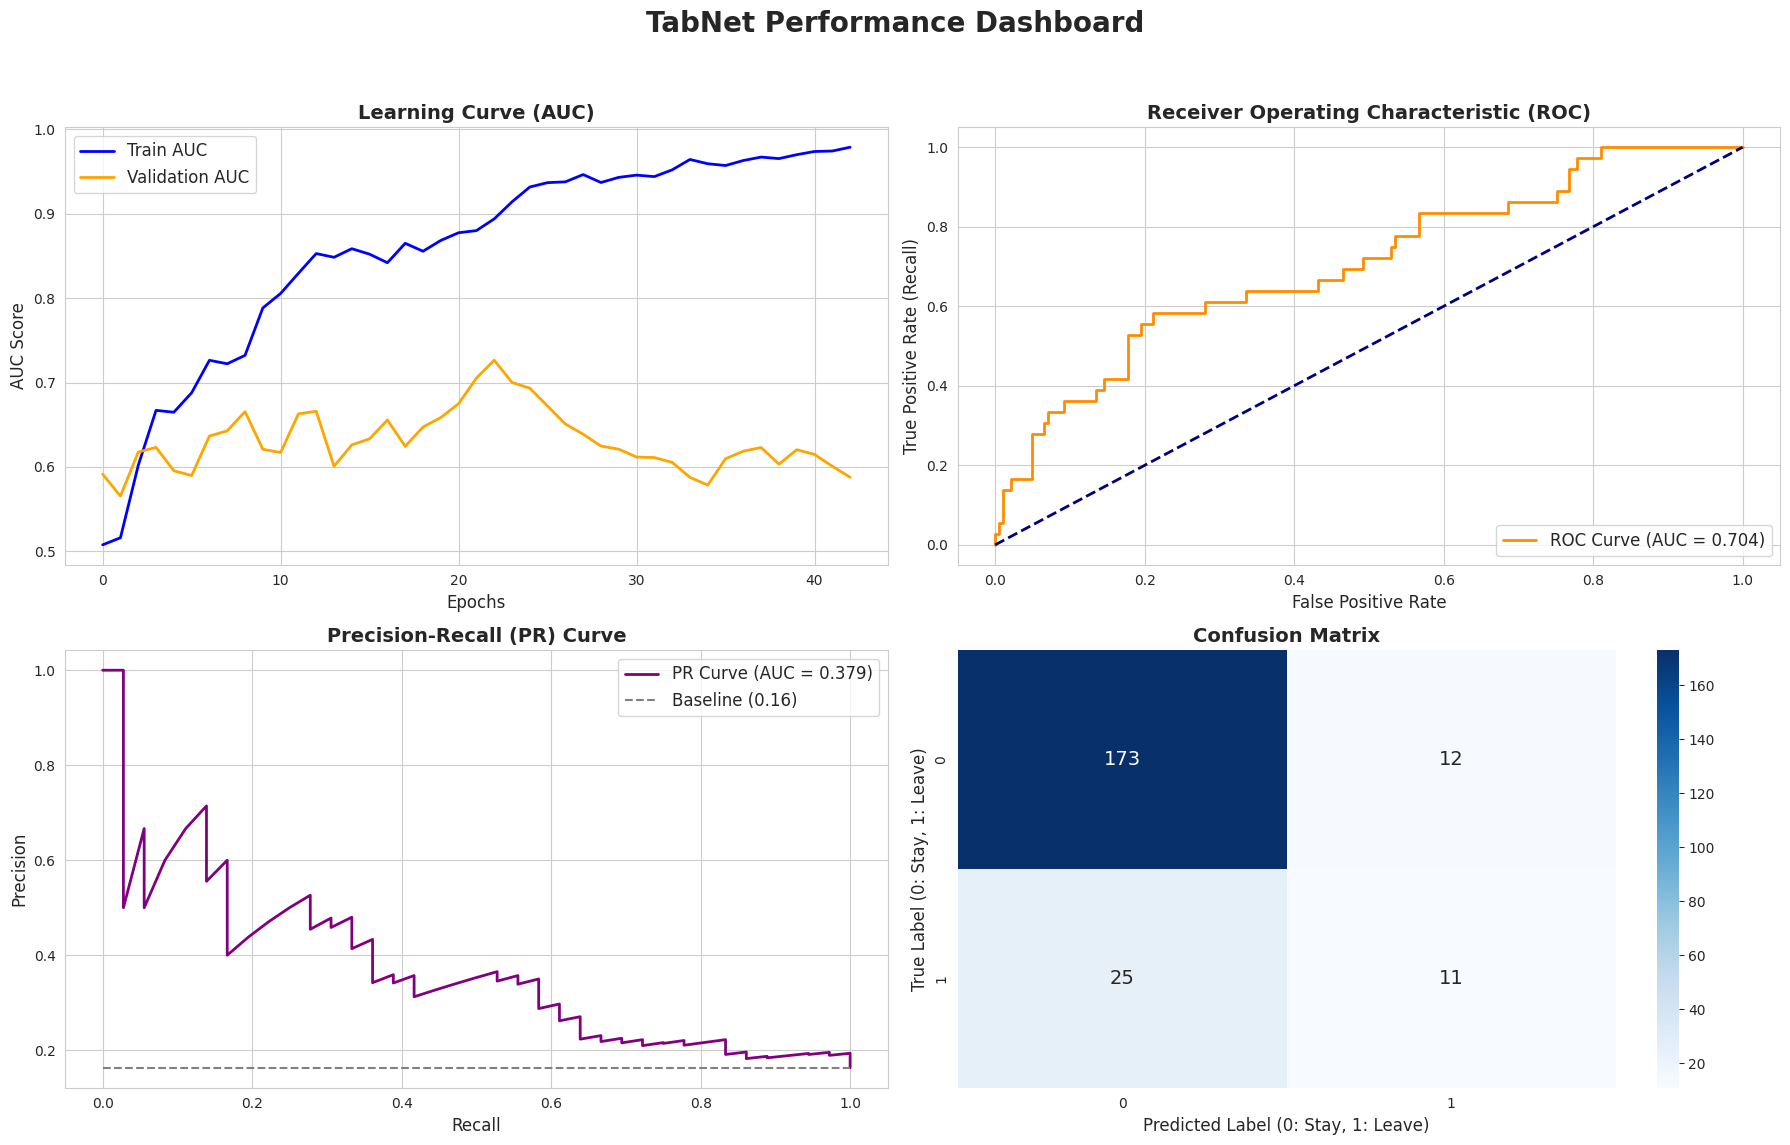

/tmp/ipykernel_6014/532342354.py:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


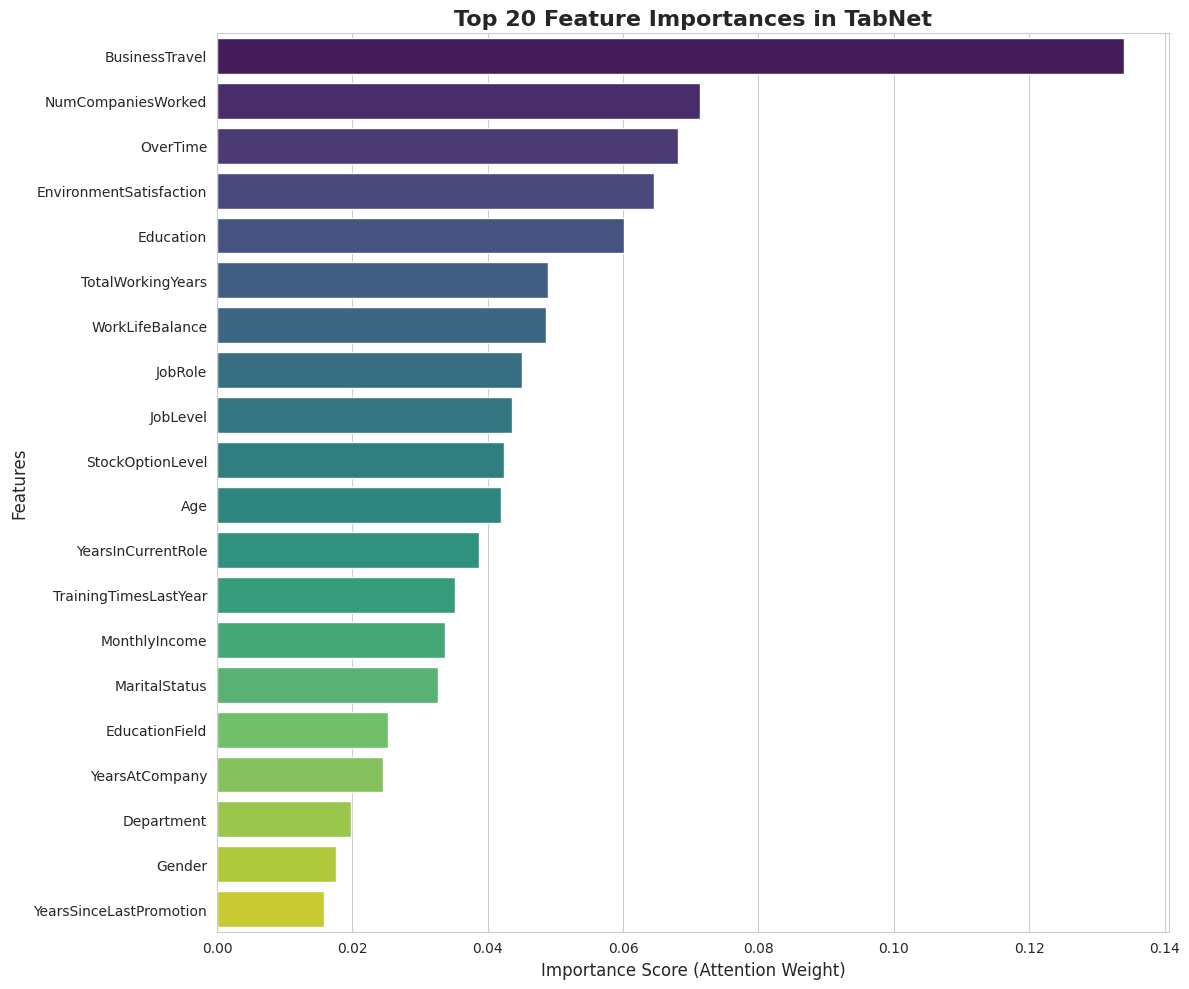


✅ [완료] 그래프가 성공적으로 PDF로 저장되었습니다: /content/drive/MyDrive/TabNet_Evaluation_Report.pdf


In [ ]:
import pandas as pd
import numpy as np
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, log_loss
# ==========================================
# 1. 데이터 로드 및 기본 설정
# ==========================================

#your_data.csv를 각자 파일 상황에 맞게 수정해서 사용하세요
df = pd.read_csv('/content/drive/MyDrive/your_data.csv')

# 랜덤 시드 설정
np.random.seed(42)

target_col = 'Attrition'
categorical_cols = ['BusinessTravel', 'Department','EducationField','Gender', 'JobRole', 'MaritalStatus', 'OverTime', ]
numerical_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'Education','EnvironmentSatisfaction','HourlyRate','JobInvolvement','JobLevel','JobSatisfaction','MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

# ==========================================
# 2. 전처리 (Preprocessing) - TabNet 맞춤형
# ==========================================

categorical_dims = {}
for col in categorical_cols:
    # 범주형 변수는 반드시 정수(0, 1, 2...)로 Label Encoding 해야 합니다.
    l_enc = LabelEncoder()
    df[col] = l_enc.fit_transform(df[col].values)
    categorical_dims[col] = len(l_enc.classes_) # 각 범주형 변수의 차원(고유값 수) 저장

# Label Encoding for the target column 'Attrition'
# The error "pos_label=1 is not a valid label. It should be one of ['No', 'Yes']"
# indicates that y_test and preds are still strings ('No', 'Yes') when metrics are calculated.
# We need to encode the target variable to numerical values (0 and 1).
# By default, LabelEncoder will sort classes alphabetically, so 'No' will be 0 and 'Yes' will be 1. This aligns with `pos_label=1`.
l_enc_target = LabelEncoder()
df[target_col] = l_enc_target.fit_transform(df[target_col].values)

# 수치형 데이터 스케일링
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Feature와 Target 분리
X = df.drop(target_col, axis=1)
y = df[target_col] # y will now contain 0s and 1s

# TabNet에 전달할 범주형 변수의 인덱스(cat_idxs)와 차원(cat_dims) 리스트 생성
features = X.columns
cat_idxs = [i for i, f in enumerate(features) if f in categorical_cols]
cat_dims = [categorical_dims[f] for i, f in enumerate(features) if f in categorical_cols]

# ==========================================
# 3. 데이터 분할 (Train / Valid / Test)
# ==========================================
# 검증용(Valid) 데이터는 딥러닝의 Early Stopping(조기 종료)을 위해 반드시 필요합니다.
X_train, X_temp, y_train, y_temp = train_test_split(X.values, y.values, test_size=0.3, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# ==========================================
# 4. TabNet 모델 정의 및 학습
# ==========================================
clf = TabNetClassifier(
    n_d=16, n_a=16, n_steps=4,          # 모델의 용량과 스텝 수 조절 (데이터가 적으면 수치를 낮추세요)
    gamma=1.3,                          # 피처 재사용 비율
    cat_idxs=cat_idxs,                  # 범주형 변수 위치
    cat_dims=cat_dims,                  # 범주형 변수 차원 (자동으로 임베딩 레이어 생성)
    cat_emb_dim=2,                      # 범주형 임베딩 차원 크기
    optimizer_fn=torch.optim.Adam,      # 옵티마이저
    optimizer_params=dict(lr=2e-2),     # 학습률
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={"step_size":10, "gamma":0.9},
    mask_type='entmax',                 # sparsemax 보다 안정적인 entmax 권장
    device_name='auto'                  # GPU 사용 가능 시 자동 할당
)

print("🚀 TabNet 학습을 시작합니다...")
clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    eval_metric=['auc'],                # 평가지표 (불균형 데이터이므로 AUC 사용)
    max_epochs=100,                     # 최대 에폭 수
    patience=20,                        # 40 에폭 동안 valid auc 개선이 없으면 조기 종료
    batch_size=256,
    virtual_batch_size=128,             # Ghost Batch Normalization 크기
    num_workers=0,
    drop_last=False
)

# ==========================================
# 5. 모델 평가 및 피처 중요도 확인
# ==========================================
# 베스트 모델을 활용한 예측
preds = clf.predict(X_test)
preds_proba = clf.predict_proba(X_test)[:, 1] # 클래스 1(퇴사)에 대한 확률값

print("\n📊 [테스트 데이터 평가 결과]")
print(f"ROC-AUC Score : {roc_auc_score(y_test, preds_proba):.4f}")
print(f"Accuracy Score: {accuracy_score(y_test, preds):.4f}")
print("\n" + classification_report(y_test, preds))

# 피처 중요도(Feature Importance) 출력
print("\n🔍 [변수 중요도 (Feature Importances)]")
feat_importances = clf.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': feat_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)

# ==========================================
# 6. 추가 성능 평가 지표 (6대 지표 계산)
# ==========================================
# 불균형 데이터에 필수적인 지표들을 모두 계산합니다.
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)
roc_auc = roc_auc_score(y_test, preds_proba)
pr_auc = average_precision_score(y_test, preds_proba)
logloss = log_loss(y_test, preds_proba)

print("\n🏆 [최종 모델 성능 평가 지표 (6 Metrics)]")
print("-" * 40)
print(f"1. Precision (정밀도) : {precision:.4f} (퇴사 예측자 중 실제 퇴사자 비율)")
print(f"2. Recall    (재현율) : {recall:.4f} (실제 퇴사자 중 찾아낸 비율)")
print(f"3. F1-Score  (F1점수) : {f1:.4f} (정밀도와 재현율의 조화평균)")
print(f"4. ROC-AUC   (ROC면적): {roc_auc:.4f} (전반적인 모델 분별력)")
print(f"5. PR-AUC    (PR면적) : {pr_auc:.4f} (★불균형 데이터 핵심 지표)")
print(f"6. Log Loss  (로그손실): {logloss:.4f} (예측 확률의 정교함, 낮을수록 좋음)")
print("-" * 40)

# ==========================================
# 7 & 8. 시각화 대시보드 및 PDF 저장
# ==========================================
# 저장할 PDF 파일 경로 설정 (Colab 드라이브 경로에 맞춤)
pdf_filepath = '/content/drive/MyDrive/TabNet_Evaluation_Report.pdf'

sns.set_style("whitegrid")

# PdfPages 객체를 열어서 그래프들을 차곡차곡 담습니다.
with PdfPages(pdf_filepath) as pdf:

    # ------------------------------------------
    # [페이지 1] 종합 성능 평가 대시보드 (2x2)
    # ------------------------------------------
    fig1 = plt.figure(figsize=(18, 12))
    fig1.suptitle("TabNet Performance Dashboard", fontsize=20, fontweight='bold')

    # 1. Learning Curve
    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(clf.history['train_auc'], label='Train AUC', color='blue', linewidth=2)
    ax1.plot(clf.history['valid_auc'], label='Validation AUC', color='orange', linewidth=2)
    ax1.set_title("Learning Curve (AUC)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Epochs", fontsize=12)
    ax1.set_ylabel("AUC Score", fontsize=12)
    ax1.legend(fontsize=12)

    # 2. ROC Curve
    ax2 = plt.subplot(2, 2, 2)
    fpr, tpr, _ = roc_curve(y_test, preds_proba)
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax2.set_title("Receiver Operating Characteristic (ROC)", fontsize=14, fontweight='bold')
    ax2.set_xlabel("False Positive Rate", fontsize=12)
    ax2.set_ylabel("True Positive Rate (Recall)", fontsize=12)
    ax2.legend(loc="lower right", fontsize=12)

    # 3. PR Curve
    ax3 = plt.subplot(2, 2, 3)
    precisions, recalls, _ = precision_recall_curve(y_test, preds_proba)
    ax3.plot(recalls, precisions, color='purple', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
    baseline = sum(y_test) / len(y_test)
    ax3.plot([0, 1], [baseline, baseline], linestyle='--', color='gray', label=f'Baseline ({baseline:.2f})')
    ax3.set_title("Precision-Recall (PR) Curve", fontsize=14, fontweight='bold')
    ax3.set_xlabel("Recall", fontsize=12)
    ax3.set_ylabel("Precision", fontsize=12)
    ax3.legend(loc="upper right", fontsize=12)

    # 4. Confusion Matrix
    ax4 = plt.subplot(2, 2, 4)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4, annot_kws={"size": 14})
    ax4.set_title("Confusion Matrix", fontsize=14, fontweight='bold')
    ax4.set_xlabel("Predicted Label (0: Stay, 1: Leave)", fontsize=12)
    ax4.set_ylabel("True Label (0: Stay, 1: Leave)", fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 타이틀과 그래프가 겹치지 않도록 여백 조정

    # 완성된 첫 번째 Figure를 PDF의 첫 페이지로 저장
    pdf.savefig(fig1)
    plt.show() # 화면에도 출력
    plt.close(fig1) # 메모리 확보를 위해 닫기

    # ------------------------------------------
    # [페이지 2] Feature Importance
    # ------------------------------------------
    fig2 = plt.figure(figsize=(12, 10))
    top_n = 20
    sns.barplot(
        x='Importance',
        y='Feature',
        data=importance_df.head(top_n),
        palette='viridis'
    )
    plt.title(f"Top {top_n} Feature Importances in TabNet", fontsize=16, fontweight='bold')
    plt.xlabel("Importance Score (Attention Weight)", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.tight_layout()

    # 완성된 두 번째 Figure를 PDF의 두 번째 페이지로 저장
    pdf.savefig(fig2)
    plt.show() # 화면에도 출력
    plt.close(fig2)

print(f"\n✅ [완료] 그래프가 성공적으로 PDF로 저장되었습니다: {pdf_filepath}")